# Load Library

In [3]:
# -------------------------
# Core Python & Scientific
# -------------------------
import os
import re
import math
import gc
import random
import itertools


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.widgets import Slider
from scipy.ndimage import distance_transform_edt
import scipy.ndimage

# -------------------------
# PyTorch Core
# -------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from torch.autograd import Variable
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# -------------------------
# MONAI (Medical AI)
# -------------------------
from monai.transforms import (
    Compose,
    CropForegroundd,
    RandAffine,
    RandAffineD,
    RandCropByPosNegLabeld,
    ResizeWithPadOrCropd,
    ScaleIntensityd,
    ToTensord,
    EnsureChannelFirst
)
from monai.metrics import DiceMetric
from monai.losses import DiceCELoss

# -------------------------
# MedPy
# -------------------------
from medpy.metric.binary import hd95, assd

# -------------------------
# Scikit-learn
# -------------------------
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# -------------------------
# Others
# -------------------------
from tqdm import tqdm
import nibabel as nib
import ipywidgets as widgets
from IPython.display import display
from concurrent.futures import ProcessPoolExecutor
from medpy.metric import binary
from joblib import Parallel, delayed
import optuna
from optuna.samplers import TPESampler
from torch_geometric.nn import DynamicEdgeConv
from torch_geometric.nn import GATConv
from torch_cluster import radius_graph
from torch_geometric.data import Data, Batch  
from torch_geometric.nn import SAGEConv
from einops import rearrange


from torch_geometric.nn import global_mean_pool
from torch_geometric.nn.aggr import AttentionalAggregation
from torch_geometric.utils import to_dense_batch
from torch_geometric.nn.pool import global_max_pool
from torch_geometric.nn import radius_graph

ImportError: cannot import name 'GradScaler' from 'torch.amp' (/opt/anaconda3/lib/python3.11/site-packages/torch/amp/__init__.py)

In [ ]:
import torch
print(torch.__version__)


# Data Loading Function

In [5]:
# 1) Preprocessing functions


def percentile_normalize(image, lower=0.5, upper=99.5):
    mask = image > 0
    if not mask.any():
        return image
    lo = np.percentile(image[mask], lower)
    hi = np.percentile(image[mask], upper)
    img = np.clip(image, lo, hi)
    return (img - img[mask].mean()) / (img[mask].std() + 1e-8)

def pad_depth(vol, target_depth=160):
    is_tensor = isinstance(vol, torch.Tensor)
    
    if is_tensor:
        current_depth = vol.shape[-1]
        diff = current_depth - target_depth

        if diff > 0:
            # Crop equally from both ends
            front_crop = diff % 2
            back_crop = diff - front_crop
            return vol[..., front_crop:-back_crop]
        elif diff < 0:
            # Pad equally on both ends
            front_pad = (-diff) // 2
            back_pad = (-diff) - front_pad
            return F.pad(vol, (front_pad, back_pad))
        else:
            return vol  # already correct size

    else:  # numpy
        current_depth = vol.shape[-1]
        diff = current_depth - target_depth

        if diff > 0:
            front_crop = diff // 2
            back_crop = diff - front_crop
            return vol[..., front_crop:-back_crop]
        elif diff < 0:
            front_pad = (-diff) // 2
            back_pad = (-diff) - front_pad
            return np.pad(vol, [(0, 0)] * (vol.ndim - 1) + [(front_pad, back_pad)], mode='constant')
        else:
            return vol
            
def center_crop_xy(img, lbl, size = 192):
    C, H, W, D = img.shape
    sh = (H - size)//2
    sw = (W - size)//2
    img = img[:, sh:sh+size, sw:sw+size, :]
    lbl = lbl[sh:sh+size, sw:sw+size, :]
    return img, lbl


# 2) Dataset Class


class BraTSLazyDataset(Dataset):
    def __init__(self, feature_dir, target_dir,
                 modalities=['t1n','t1c','t2f','t2w'],
                 crop_val=False, subject_ids=None):
        self.feature_dir = feature_dir
        self.target_dir  = target_dir
        self.modalities  = modalities
        self.crop_val    = crop_val

        if subject_ids is None:
            all_files = os.listdir(feature_dir)
            subjs = {f.split('__')[0] for f in all_files if f.endswith('.nii.gz')}
            self.subject_ids = sorted(subjs)
        else:
            self.subject_ids = list(subject_ids)

    def __len__(self):
        return len(self.subject_ids)

    def __getitem__(self, idx):
        sid = self.subject_ids[idx]
        vols = []
        for m in self.modalities:
            path = os.path.join(self.feature_dir, f"{sid}__{sid}-{m}.nii.gz")
            img = nib.load(path).get_fdata()
            # img = percentile_normalize(img)
            vols.append(img)
        image = np.stack(vols, axis=0)  # (C, H, W, D)

        label_path = os.path.join(self.target_dir, f"{sid}__{sid}-seg.nii.gz")
        label = nib.load(label_path).get_fdata().astype(np.int64)  # (H, W, D)

        # convert to tensor and pad depth
        image = torch.from_numpy(pad_depth(image)).float()
        label = torch.from_numpy(pad_depth(label)).long()

        # optional crop for val set
        if self.crop_val:
            image, label = center_crop_xy(image, label, size = 176)

        return image, label


# 3) Split function


def get_train_val_datasets(feature_dir, target_dir,
                           train_ratio=0.8, limit_subjects=None, seed=42):
    all_files = os.listdir(feature_dir)
    subjs = sorted({f.split('__')[0] for f in all_files if f.endswith('.nii.gz')})
    if limit_subjects:
        subjs = subjs[:limit_subjects]

    torch.manual_seed(seed)
    n = len(subjs)
    n_train = int(train_ratio * n)
    train_ids, val_ids = random_split(subjs, [n_train, n - n_train])

    train_ds = BraTSLazyDataset(feature_dir, target_dir, crop_val=False, subject_ids=train_ids)
    val_ds   = BraTSLazyDataset(feature_dir, target_dir, crop_val=True,  subject_ids=val_ids)

    return train_ds, val_ds


# Data Loading 

In [6]:
feature_dir = "/workspace/BraTS_features"
target_dir  = "/workspace/BraTS_target"

train_dataset, val_dataset = get_train_val_datasets(
    feature_dir, target_dir,
    train_ratio=0.8,
    limit_subjects=400,
    seed=4200
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/BraTS_features'

In [9]:
pre_train_loader = DataLoader(
    train_dataset,
    batch_size=3,
    shuffle=True
)

pre_val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

imgs, lbls = next(iter(pre_train_loader))
print("Input shape: ", imgs.shape)  
print("Label shape:", lbls.shape)   

imgs, lbls = next(iter(pre_val_loader))
print("Input shape: ", imgs.shape)  
print("Label shape:", lbls.shape) 

Input shape:  torch.Size([3, 4, 240, 240, 160])
Label shape: torch.Size([3, 240, 240, 160])
Input shape:  torch.Size([2, 4, 176, 176, 160])
Label shape: torch.Size([2, 176, 176, 160])


# GNN Preprocessing

In [36]:
class PatchGNNPreprocessor(nn.Module):
    def __init__(self, in_channels=4, patch_size=8, hidden_dim=128, out_channels=None, r=32, num_classes=4):
        super().__init__()
        self.patch_size = patch_size
        self.r = r
        self.out_channels = out_channels or in_channels
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes

        self.feat_proj = nn.Linear(in_channels * patch_size**3, hidden_dim)
        self.gnn = SAGEConv(hidden_dim, hidden_dim)
        self.post_proj = nn.Linear(hidden_dim, in_channels * patch_size**3)
        self.residual_proj = nn.Linear(in_channels * patch_size**3, hidden_dim)

        # Segmentation head with learnable scaling for each class (boosting underperforming classes)
        self.segmentation_head = nn.Sequential(
            nn.Conv3d(hidden_dim, hidden_dim, kernel_size=1),
            nn.ReLU(),
            nn.Conv3d(hidden_dim, num_classes, kernel_size=1)
        )
        self.class_scaler = nn.Parameter(torch.tensor([1.0, 1.0, 1.0, 2.0]))  # Boost class 3 output

    def forward(self, x, return_embedding=False):
        B, C, D, H, W = x.shape
        P = self.patch_size
        assert D % P == 0 and H % P == 0 and W % P == 0, "Input size must be divisible by patch size"

        x_patch = rearrange(x, 'b c (d p1) (h p2) (w p3) -> b (d h w) (c p1 p2 p3)', p1=P, p2=P, p3=P)
        D_, H_, W_ = D // P, H // P, W // P
        device = x.device

        recon_outputs, seg_logits_all, all_patch_embeddings = [], [], []

        for i in range(B):
            patch_feats = x_patch[i]
            patch_feats = (patch_feats - patch_feats.mean(dim=-1, keepdim=True)) / (patch_feats.std(dim=-1, keepdim=True) + 1e-6)

            coords = self._make_coords(D_, H_, W_, device)
            edge_index = radius_graph(coords, r=self.r, loop=True)
            if edge_index.numel() == 0:
                edge_index = dense_to_sparse(torch.ones((coords.size(0), coords.size(0)), device=device))[0]

            node_feats = self.feat_proj(patch_feats)
            residual = self.residual_proj(patch_feats)
            gnn_out = self.gnn(node_feats, edge_index) + residual

            # Segmentation head
            patch_feats_3d = gnn_out.view(D_, H_, W_, self.hidden_dim).permute(3, 0, 1, 2).unsqueeze(0)  # (1, hidden_dim, D', H', W')
            seg_logits = self.segmentation_head(patch_feats_3d)  # (1, num_classes, D', H', W')
            seg_logits *= self.class_scaler.view(1, -1, 1, 1, 1)  # Apply class-wise boosting

            seg_logits_up = F.interpolate(seg_logits, size=(D, H, W), mode='nearest')  # Nearest to preserve sharp boundaries
            seg_logits_all.append(seg_logits_up)

            # Reconstruction
            proj_out = self.post_proj(gnn_out)
            recon = proj_out.view(D_, H_, W_, C, P, P, P).permute(3, 0, 4, 1, 5, 2, 6).contiguous()
            recon = recon.view(C, D, H, W).clamp(-1.0, 1.0)
            recon_outputs.append(recon.unsqueeze(0))

            if return_embedding:
                all_patch_embeddings.append(gnn_out)

        recon_batch = torch.cat(recon_outputs, dim=0)
        seg_logits_batch = torch.cat(seg_logits_all, dim=0)

        if return_embedding:
            return recon_batch, seg_logits_batch, all_patch_embeddings
        else:
            return recon_batch, seg_logits_batch

    def _make_coords(self, D_, H_, W_, device):
        zz, yy, xx = torch.meshgrid(
            torch.arange(D_, device=device),
            torch.arange(H_, device=device),
            torch.arange(W_, device=device),
            indexing='ij'
        )
        return torch.stack([zz, yy, xx], dim=-1).reshape(-1, 3).float()


In [37]:
class MultiTaskPatchGNNSegmentationLoss(nn.Module):
    def __init__(self,
                 lambda_recon=0.0,
                 lambda_seg=0.0,
                 lambda_contrastive=0.5,
                 temperature=0.1,
                 contrastive_type='simclr'):
        super().__init__()
        self.seg_loss_fn = nn.CrossEntropyLoss()
        self.lambda_recon = lambda_recon
        self.lambda_seg = lambda_seg
        self.lambda_contrastive = lambda_contrastive
        self.temperature = temperature
        self.contrastive_type = contrastive_type.lower()

    def forward(self, recon_x, x_orig, seg_logits, seg_labels, proj1_list=None, proj2_list=None):
        loss_recon = F.smooth_l1_loss(recon_x, x_orig, beta=1.0)

        loss_seg = self.seg_loss_fn(seg_logits, seg_labels.long())

        if self.contrastive_type == 'simclr':
            loss_contrastive = self._simclr_loss(proj1_list, proj2_list)
        elif self.contrastive_type == 'byol':
            loss_contrastive = self._byol_loss(proj1_list, proj2_list)
        else:
            raise ValueError(f"Unsupported contrastive type: {self.contrastive_type}")

        total_loss = (
            self.lambda_recon * loss_recon +
            self.lambda_seg * loss_seg +
            self.lambda_contrastive * loss_contrastive
        )

        logs = {
            "recon": loss_recon.item(),
            "seg": loss_seg.item(),
            "contrastive": loss_contrastive.item(),  # 🔁 change to fixed name
            "total": total_loss.item()
        }


        return total_loss, logs

    def _byol_loss(self, proj1_list, proj2_list):
        losses = []
        for z1, z2 in zip(proj1_list, proj2_list):
            z1 = F.normalize(z1, dim=-1, eps=1e-6)
            z2 = F.normalize(z2, dim=-1, eps=1e-6)
            loss = 2 - 2 * (z1 * z2).sum(dim=-1).mean()
            losses.append(loss)
        return torch.stack(losses).mean()

    def _simclr_loss(self, proj1_list, proj2_list):
        temperature = self.temperature
        max_nodes = 8192
        all_losses = []
    
        for z1, z2 in zip(proj1_list, proj2_list):
            z1 = F.normalize(z1, dim=-1)
            z2 = F.normalize(z2, dim=-1)
    
            # Truncate to max_nodes to reduce memory
            if z1.shape[0] > max_nodes:
                idx = torch.randperm(z1.shape[0], device=z1.device)[:max_nodes]
                z1 = z1[idx]
                z2 = z2[idx]
    
            N = z1.size(0)
            reps = torch.cat([z1, z2], dim=0)  # (2N, D)
    
            # Efficient cosine similarity via dot product
            sim_matrix = torch.mm(reps, reps.t())  # (2N, 2N)
            sim_matrix = sim_matrix / temperature
    
            # Mask out self-similarity
            mask = torch.eye(2 * N, dtype=torch.bool, device=z1.device)
            sim_matrix = sim_matrix.masked_fill(mask, float('-inf'))
    
            # Construct ground truth indices for positive pairs
            labels = torch.arange(N, device=z1.device)
            labels = torch.cat([labels + N, labels], dim=0)
    
            # Compute contrastive loss
            loss = F.cross_entropy(sim_matrix, labels)
            all_losses.append(loss)
    
        return torch.stack(all_losses).mean()


In [38]:
# --------------------- Dice per Class ---------------------
def compute_dice_per_class(pred, target, num_classes):
    scores = []
    for cls in range(num_classes):
        pred_bin = (pred == cls).float()
        target_bin = (target == cls).float()
        intersection = (pred_bin * target_bin).sum()
        union = pred_bin.sum() + target_bin.sum()
        dice = (2. * intersection / (union + 1e-5)) if union > 0 else torch.tensor(1.0)
        scores.append(dice)
    return torch.tensor(scores)

# --------------------- Validation ---------------------
def validate(model, dataloader, device='cuda'):
    model.eval()
    dice_scores = []

    with torch.no_grad():
        for x, y_seg in tqdm(dataloader, desc="Validation"):
            x, y_seg = x.to(device, non_blocking=True), y_seg.to(device, non_blocking=True)

            recon_x, seg_logits = model(x, return_embedding=False)
            preds = torch.argmax(seg_logits, dim=1)  # (B, D, H, W)

            for i in range(preds.shape[0]):
                dice = compute_dice_per_class(preds[i], y_seg[i], num_classes=seg_logits.shape[1])
                dice_scores.append(dice)

    dice_scores = torch.stack(dice_scores)
    mean_dice = dice_scores.mean(dim=0)
    print("\n[Validation Summary]")
    for c, d in enumerate(mean_dice):
        print(f"  Dice Class {c}: {d:.4f}")
    print(f"  Mean Dice: {mean_dice.mean():.4f}")

# --------------------- Pretraining Phase ---------------------
def phase1_pretrain(
    model,
    train_loader,
    val_loader,
    optimizer,
    multitask_loss_fn,
    scheduler=None,
    num_epochs=50,
    device='cuda'
):
    scaler = GradScaler()
    model.to(device)

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_logs = {"recon": 0.0, "seg": 0.0, "contrastive": 0.0, "total": 0.0}
        print(f"\n[Epoch {epoch}/{num_epochs}]")

        for x, y_seg in tqdm(train_loader, desc="Training"):
            x, y_seg = x.to(device, non_blocking=True), y_seg.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(dtype=torch.float16, device_type='cuda'):
                recon_x, seg_logits, proj1 = model(x, return_embedding=True)
                _, _, proj2 = model(x, return_embedding=True)

                loss, logs = multitask_loss_fn(
                    recon_x=recon_x,
                    x_orig=x,
                    seg_logits=seg_logits,
                    seg_labels=y_seg,
                    proj1_list=proj1,
                    proj2_list=proj2
                )
                loss = torch.clamp(loss, min=0.0, max=100.0)

            if torch.isnan(loss).any():
                print("[Warning] NaN loss encountered. Skipping batch.")
                continue

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            for k in logs:
                total_logs[k] += logs[k]

        # Epoch summary
        n = len(train_loader)
        print(f"[Epoch {epoch} Summary]")
        print(f"  Recon Loss: {total_logs['recon'] / n:.4f}")
        print(f"  Seg   Loss: {total_logs['seg'] / n:.4f}")
        print(f"  Contrastive Loss: {total_logs['contrastive'] / n:.4f}")
        print(f"  Total Loss: {total_logs['total'] / n:.4f}")

        if scheduler:
            scheduler.step()

        torch.cuda.empty_cache()
        gc.collect()

        validate(model, val_loader, device=device)


In [39]:
model = PatchGNNPreprocessor(
    in_channels=4,          # e.g., T1n, T1c, T2w, T2f
    patch_size=4,           # must divide input shape like 192x192x160
    hidden_dim=128,
    num_classes=4           # for segmentation (tumor labels)
)


loss_fn = MultiTaskPatchGNNSegmentationLoss(
    lambda_recon=0.001,
    lambda_seg=1.0,
    lambda_contrastive=0.01,
    temperature=0.1,
    contrastive_type='simclr'  # Or 'byol'
)


optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


phase1_pretrain(
    model=model,
    train_loader=pre_train_loader,
    val_loader = pre_val_loader,
    optimizer=optimizer,
    multitask_loss_fn=loss_fn,
    scheduler=scheduler,
    num_epochs=50,
    device='cuda'
)



[Epoch 1/50]


Training: 100%|██████████| 107/107 [05:03<00:00,  2.84s/it]


[Epoch 1 Summary]
  Recon Loss: 1842.0129
  Seg   Loss: 1.0593
  Contrastive Loss: 8.4206
  Total Loss: 2.9855


Validation: 100%|██████████| 40/40 [01:01<00:00,  1.53s/it]



[Validation Summary]
  Dice Class 0: 0.9885
  Dice Class 1: 0.6251
  Dice Class 2: 0.4410
  Dice Class 3: 0.0018
  Mean Dice: 0.5141

[Epoch 2/50]


...

[Epoch 3 Summary]
  Recon Loss: 1842.3985
  Seg   Loss: 0.0707
  Contrastive Loss: 8.6812
  Total Loss: 1.9999


Validation: 100%|██████████| 40/40 [01:00<00:00,  1.52s/it]



[Validation Summary]
  Dice Class 0: 0.9969
  Dice Class 1: 0.6875
  Dice Class 2: 0.5375
  Dice Class 3: 0.0000
  Mean Dice: 0.5555

[Epoch 4/50]


Training:  15%|█▍        | 16/107 [00:43<04:05,  2.69s/it]


KeyboardInterrupt: 

In [ ]:
num_epochs = 5
scaler = GradScaler()

for epoch in range(1, num_epochs + 1):
    print(f"\n========== Epoch {epoch}/{num_epochs} ==========")

    # -------- TRAINING --------
    model.train()
    total_train_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Training Epoch {epoch}", leave=False)

    for imgs, lbls in train_bar:
        imgs, lbls = imgs.cuda(), lbls.cuda()

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda'):
            logits = model(imgs)
            loss = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()
        train_bar.set_postfix(train_loss=f"{loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"[Epoch {epoch}] Train Loss: {avg_train_loss:.4f}")

    # -------- VALIDATION --------
    model.eval()
    total_val_loss = 0.0
    val_bar = tqdm(val_loader, desc=f"Validation Epoch {epoch}", leave=False)

    with torch.no_grad():
        for imgs, lbls in val_bar:
            imgs, lbls = imgs.cuda(), lbls.cuda()
            with autocast(device_type='cuda'):
                logits = model(imgs)
                val_loss = criterion(logits, lbls)

            total_val_loss += val_loss.item()
            val_bar.set_postfix(val_loss=f"{val_loss.item():.4f}")

    avg_val_loss = total_val_loss / len(val_loader)
    print(f"[Epoch {epoch}] Val Loss: {avg_val_loss:.4f}")


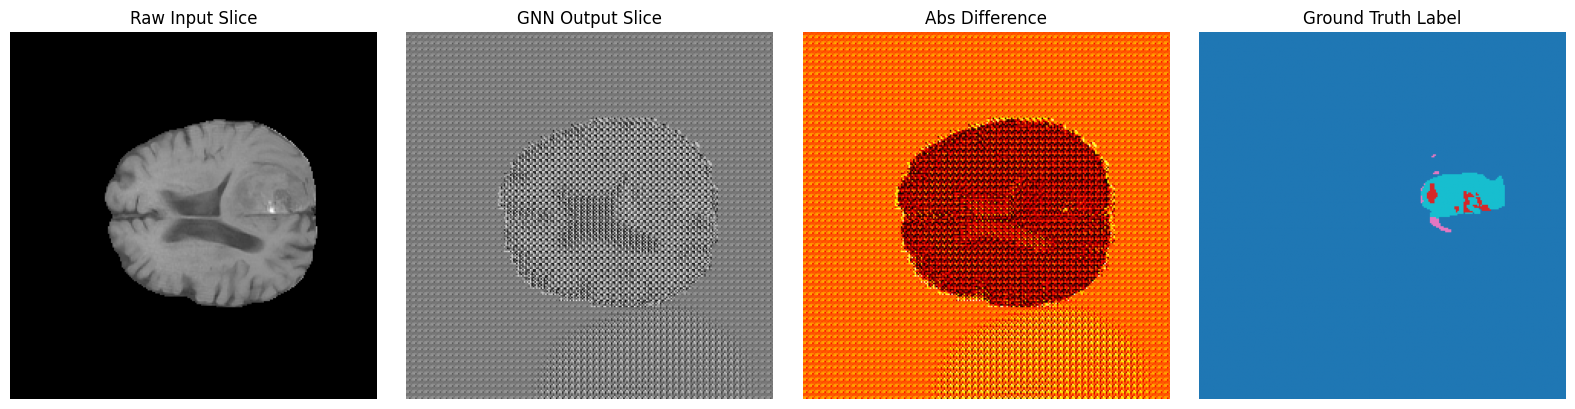

In [35]:
# 1. Get a single batch from train_loader
raw_input, labels = next(iter(pre_train_loader))  # raw_input: (B, 4, 240, 240, 160), labels: (B, 240, 240, 160)

# 2. Move to GPU if needed
raw_input = raw_input.cuda()

# 3. GNN forward pass
with torch.no_grad():
    recon_x, _ = model(raw_input, return_embedding=False)  # ← Fix here

# ---- Visualization settings ----
modality_idx = 0     # Choose modality: 0=t1n, 1=t1c, 2=t2f, 3=t2w
depth_idx    = 90   # Choose z-slice to visualize

# Normalize helper
def normalize(img):
    img = img.cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

# Get normalized slices
raw_slice   = normalize(raw_input[0, modality_idx, :, :, depth_idx])
gnn_slice   = normalize(recon_x[0, modality_idx, :, :, depth_idx])
diff_slice  = abs(raw_slice - gnn_slice)

# Get label slice (no normalization needed for class labels)
label_slice = labels[0, :, :, depth_idx].cpu().numpy()

# ---- Plot ----
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(raw_slice, cmap='gray')
plt.title("Raw Input Slice")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(gnn_slice, cmap='gray')
plt.title("GNN Output Slice")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(diff_slice, cmap='hot')
plt.title("Abs Difference")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(label_slice, cmap='tab10')
plt.title("Ground Truth Label")
plt.axis('off')

plt.tight_layout()
plt.show()


In [30]:
class GNNEncodedCroppedDataset(Dataset):
    def __init__(self, raw_dataset, gnn_model, crop_size=(176, 176, 176)):
        self.raw_dataset = raw_dataset
        self.gnn_model = gnn_model.eval().cuda()
        self.crop_size = crop_size

    def __len__(self):
        return len(self.raw_dataset)

    def __getitem__(self, idx):
        # Original volume and label
        x, y = self.raw_dataset[idx]  # x: (4, D, H, W), y: (D, H, W)

        with torch.no_grad():
            # Only take the first output (reconstructed or patch-enhanced features)
            x_gnn = self.gnn_model(x.unsqueeze(0).cuda())[0]  # Take first tensor from tuple
            x_gnn = x_gnn.squeeze(0).cpu()  # (4, D, H, W)

        # Get crop coordinates
        _, D, H, W = x_gnn.shape
        cd, ch, cw = self.crop_size
        d = random.randint(0, D - cd)
        h = random.randint(0, H - ch)
        w = random.randint(0, W - cw)

        # Crop features and labels
        x_crop = x_gnn[:, d:d+cd, h:h+ch, w:w+cw]
        y_crop = y[d:d+cd, h:h+ch, w:w+cw]

        return x_crop, y_crop


In [236]:
def create_phase2_loaders(train_dataset, val_dataset, gnn_model, crop_size=(96, 96, 96),
                          batch_size=4, num_workers=2):
    # GNN-processed + cropped training loader
    train_gnn_dataset = GNNEncodedCroppedDataset(train_dataset, gnn_model, crop_size)
    train_loader = DataLoader(train_gnn_dataset, batch_size=batch_size,
                              shuffle=True)

    # Use raw val_dataset directly
    val_loader = DataLoader(val_dataset, batch_size=2,
                            shuffle=False)

    return train_loader, val_loader


In [237]:
train_loader, val_loader = create_phase2_loaders(train_dataset, val_dataset, gnn_model=model)

imgs, lbls = next(iter(train_loader))
print("Train Input shape: ", imgs.shape)  
print("Train Label shape:", lbls.shape) 

imgs, lbls = next(iter(val_loader))
print("Val Input shape: ", imgs.shape)  
print("Val Label shape:", lbls.shape) 

# Number of samples
num_train_samples = len(train_loader.dataset)
num_val_samples = len(val_loader.dataset)

# Batch sizes
train_batch_size = train_loader.batch_size
val_batch_size = val_loader.batch_size

# Number of batches
num_train_batches = len(train_loader)
num_val_batches = len(val_loader)

print(f"Train: {num_train_samples} samples in {num_train_batches} batches (batch size = {train_batch_size})")
print(f"Val:   {num_val_samples} samples in {num_val_batches} batches (batch size = {val_batch_size})")


Train Input shape:  torch.Size([4, 4, 96, 96, 96])
Train Label shape: torch.Size([4, 96, 96, 96])
Val Input shape:  torch.Size([2, 4, 192, 192, 160])
Val Label shape: torch.Size([2, 192, 192, 160])
Train: 140 samples in 35 batches (batch size = 4)
Val:   60 samples in 30 batches (batch size = 2)


# Tumor Patch Function

In [ ]:
class FixedSizeTumorPatchDataset(Dataset):
    def __init__(self, base_dataset, patch_size, ratios=(0.5, 0.3, 0.2)):
        self.base_dataset = base_dataset
        self.patch_size = patch_size
        self.ratios = ratios

        self.tumor_indices = []
        self.tumor_voxel_coords = {}

        print(f"Precomputing tumor indices for patch size: {patch_size}...")
        for idx in tqdm(range(len(base_dataset)), desc=f"Building Tumor Index ({patch_size})"):
            _, label = base_dataset[idx]
            if torch.any(label > 0):
                self.tumor_indices.append(idx)
                coords = (label > 0).nonzero(as_tuple=False)
                self.tumor_voxel_coords[idx] = coords
        print(f" Found {len(self.tumor_indices)} samples with tumor regions.")

        self.total_len = len(base_dataset)

    def __len__(self):
        return self.total_len

    def __getitem__(self, _):
        pH, pW, pD = self.patch_size
        mode = random.choices(['tumor', 'hardneg', 'random'], weights=self.ratios, k=1)[0]

        if mode == 'tumor' and self.tumor_indices:
            dataset_idx = random.choice(self.tumor_indices)
        else:
            dataset_idx = random.randint(0, len(self.base_dataset) - 1)

        image, label = self.base_dataset[dataset_idx]
        C, H, W, D = image.shape

        # Padding if needed
        pad_H = max(pH - H, 0)
        pad_W = max(pW - W, 0)
        pad_D = max(pD - D, 0)
        if pad_H or pad_W or pad_D:
            image = F.pad(image, (0, pad_D, 0, pad_W, 0, pad_H))
            label = F.pad(label, (0, pad_D, 0, pad_W, 0, pad_H))
            _, H, W, D = image.shape

        for attempt in range(10):
            if mode == 'tumor' and dataset_idx in self.tumor_voxel_coords:
                tumor_voxels = self.tumor_voxel_coords[dataset_idx]
                rand_idx = random.randint(0, tumor_voxels.shape[0] - 1)
                h, w, d = tumor_voxels[rand_idx].tolist()
                x = min(max(h - pH // 2, 0), H - pH)
                y = min(max(w - pW // 2, 0), W - pW)
                z = min(max(d - pD // 2, 0), D - pD)
                patch_label = label[x:x+pH, y:y+pW, z:z+pD]
                if (patch_label > 0).any():
                    break
            elif mode == 'hardneg':
                x = random.randint(0, H - pH)
                y = random.randint(0, W - pW)
                z = random.randint(0, D - pD)
                patch_label = label[x:x+pH, y:y+pW, z:z+pD]
                if patch_label.sum() == 0:
                    break
            else:  # random
                x = random.randint(0, H - pH)
                y = random.randint(0, W - pW)
                z = random.randint(0, D - pD)
                break
        else:
            x = random.randint(0, H - pH)
            y = random.randint(0, W - pW)
            z = random.randint(0, D - pD)

        image_patch = image[:, x:x+pH, y:y+pW, z:z+pD]
        label_patch = label[x:x+pH, y:y+pW, z:z+pD]

        assert image_patch.shape[1:] == label_patch.shape, f"Patch size mismatch: {image_patch.shape} vs {label_patch.shape}"

        return image_patch, label_patch, mode


# Model

## Swin-UNet

In [ ]:
# ---------------------- Utility Crop ----------------------
def center_crop(source, target):
    _, _, d1, h1, w1 = source.shape
    _, _, d2, h2, w2 = target.shape
    dd = (d1 - d2) // 2
    dh = (h1 - h2) // 2
    dw = (w1 - w2) // 2
    return source[:, :, dd:dd + d2, dh:dh + h2, dw:dw + w2]


# ---------------------- Patch Modules ----------------------
class PatchEmbedding3D(nn.Module):
    def __init__(self, in_channels=4, embed_dim=96, patch_size=(4, 4, 4)):
        super().__init__()
        self.proj = nn.Conv3d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x)


class PatchMerging3D(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.reduction = nn.Conv3d(in_dim, out_dim, kernel_size=2, stride=2)

    def forward(self, x):
        return self.reduction(x)


class PatchExpanding3D(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.expand = nn.ConvTranspose3d(in_dim, out_dim, kernel_size=2, stride=2)

    def forward(self, x):
        return self.expand(x)


# ---------------------- Window Partitioning ----------------------
def window_partition(x, window_size):
    B, C, D, H, W = x.shape
    x = x.view(B, C,
               D // window_size, window_size,
               H // window_size, window_size,
               W // window_size, window_size)
    x = x.permute(0, 2, 4, 6, 3, 5, 7, 1).contiguous()
    windows = x.view(-1, window_size ** 3, C)
    return windows


def window_reverse(windows, window_size, B, C, D, H, W):
    x = windows.view(B,
                    D // window_size,
                    H // window_size,
                    W // window_size,
                    window_size,
                    window_size,
                    window_size,
                    C)
    x = x.permute(0, 7, 1, 4, 2, 5, 3, 6).contiguous()
    x = x.view(B, C, D, H, W)
    return x


# ---------------------- Window Attention 3D ----------------------
class WindowAttention3D(nn.Module):
    def __init__(self, dim, window_size=4, num_heads=4, shift=False):
        super().__init__()
        self.window_size = window_size
        self.shift = shift
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)

    def forward(self, x):
        B, C, D, H, W = x.shape
        ws = self.window_size

        if self.shift:
            shift_size = ws // 2
            x = torch.roll(x, shifts=(-shift_size, -shift_size, -shift_size), dims=(2, 3, 4))

        if D % ws != 0 or H % ws != 0 or W % ws != 0:
            x_flat = x.view(B, C, -1).permute(0, 2, 1)
            out, _ = self.attn(x_flat, x_flat, x_flat)
            out = out.permute(0, 2, 1).view(B, C, D, H, W)
        else:
            windows = window_partition(x, ws)
            out, _ = self.attn(windows, windows, windows)
            out = window_reverse(out, ws, B, C, D, H, W)

        if self.shift:
            x = torch.roll(out, shifts=(+shift_size, +shift_size, +shift_size), dims=(2, 3, 4))
            return x
        else:
            return out


# ---------------------- Swin Transformer Block ----------------------
class SwinTransformerBlock3D(nn.Module):
    def __init__(self, dim, window_size=4, num_heads=4):
        super().__init__()
        self.norm1a = nn.LayerNorm(dim)
        self.attn1 = WindowAttention3D(dim, window_size, num_heads, shift=False)
        self.norm2a = nn.LayerNorm(dim)
        self.mlp1 = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

        self.norm1b = nn.LayerNorm(dim)
        self.attn2 = WindowAttention3D(dim, window_size, num_heads, shift=True)
        self.norm2b = nn.LayerNorm(dim)
        self.mlp2 = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        B, C, D, H, W = x.shape

        x_ = x.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, C)
        x_norm = self.norm1a(x_).view(B, D, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        x = x + self.attn1(x_norm)

        x_ = x.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, C)
        x_mlp = self.mlp1(self.norm2a(x_)).view(B, D, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        x = x + x_mlp

        x_ = x.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, C)
        x_norm = self.norm1b(x_).view(B, D, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        x = x + self.attn2(x_norm)

        x_ = x.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, C)
        x_mlp = self.mlp2(self.norm2b(x_)).view(B, D, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        x = x + x_mlp

        return x

# ---------------------- CBAM 3D ----------------------

class CBAM3D(nn.Module):
    def __init__(self, channels, reduction_ratio=16, kernel_size=7):
        super(CBAM3D, self).__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Conv3d(channels, channels // reduction_ratio, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv3d(channels // reduction_ratio, channels, 1, bias=False),
            nn.Sigmoid()
        )
        
        self.spatial_attention = nn.Sequential(
            nn.Conv3d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel Attention
        avg_out = self.channel_attention(x)
        x = x * avg_out
        
        # Spatial Attention
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        avg_out = torch.mean(x, dim=1, keepdim=True)
        spatial_input = torch.cat([max_out, avg_out], dim=1)
        spatial_out = self.spatial_attention(spatial_input)
        
        return x * spatial_out


# ---------------------- Swin UNet 3D ----------------------
class SwinUNet3D(nn.Module):
    def __init__(self, in_ch=4, out_ch=4, base_dim=96, deep_supervision=True):
        super().__init__()
        C = base_dim
        self.deep_supervision = deep_supervision
        self.embed = PatchEmbedding3D(in_ch, C)

        self.encoder1 = nn.Sequential(
            
            *[SwinTransformerBlock3D(C) for _ in range(2)]
        )
        self.merge1 = PatchMerging3D(C, 2 * C)

        self.encoder2 = nn.Sequential(
            
            *[SwinTransformerBlock3D(2 * C) for _ in range(2)]
        )
        self.merge2 = PatchMerging3D(2 * C, 4 * C)

        self.encoder3 = nn.Sequential(
            
            *[SwinTransformerBlock3D(4 * C) for _ in range(2)]
        )
        self.merge3 = PatchMerging3D(4 * C, 8 * C)

        self.bottleneck = nn.Sequential(
            SwinTransformerBlock3D(8 * C),
            SwinTransformerBlock3D(8 * C)
        )

        self.expand3 = PatchExpanding3D(8 * C, 4 * C)
        self.decoder3 = nn.Sequential(
            
            *[SwinTransformerBlock3D(4 * C) for _ in range(2)]
        )

        self.expand2 = PatchExpanding3D(4 * C, 2 * C)
        self.decoder2 = nn.Sequential(
            
            *[SwinTransformerBlock3D(2 * C) for _ in range(2)]
        )

        self.expand1 = PatchExpanding3D(2 * C, C)
        self.decoder1 = nn.Sequential(
            
            *[SwinTransformerBlock3D(C) for _ in range(2)]
        )

        self.final = nn.Conv3d(C, out_ch, kernel_size=1)

        if self.deep_supervision:
            self.out3 = nn.Conv3d(4 * C, out_ch, kernel_size=1)
            self.out2 = nn.Conv3d(2 * C, out_ch, kernel_size=1)

    def forward(self, x):
        skips = []
        x = self.embed(x)

        x1 = self.encoder1(x); skips.append(x1)
        x = self.merge1(x1)

        x2 = self.encoder2(x); skips.append(x2)
        x = self.merge2(x2)

        x3 = self.encoder3(x); skips.append(x3)
        x = self.merge3(x3)

        x = self.bottleneck(x)

        x = self.expand3(x)
        d3 = self.decoder3(x + center_crop(skips.pop(), x))

        x = self.expand2(d3)
        d2 = self.decoder2(x + center_crop(skips.pop(), x))

        x = self.expand1(d2)
        d1 = self.decoder1(x + center_crop(skips.pop(), x))

        out = self.final(d1)

        if self.deep_supervision:
            out_d2 = F.interpolate(self.out2(d2), size=out.shape[2:], mode='trilinear', align_corners=False)
            out_d3 = F.interpolate(self.out3(d3), size=out.shape[2:], mode='trilinear', align_corners=False)
            return [out, out_d2, out_d3]
        else:
            return out





## Hybrid Attention UNet

In [239]:
# ---------------------- Utility Crop ----------------------
def center_crop(source, target):
    _, _, d1, h1, w1 = source.shape
    _, _, d2, h2, w2 = target.shape
    dd = (d1 - d2) // 2
    dh = (h1 - h2) // 2
    dw = (w1 - w2) // 2
    return source[:, :, dd:dd + d2, dh:dh + h2, dw:dw + w2]

# ---------------------- Window Partitioning ----------------------
def window_partition(x, window_size):
    B, C, D, H, W = x.shape
    x = x.view(B, C, D // window_size, window_size, H // window_size, window_size, W // window_size, window_size)
    x = x.permute(0, 2, 4, 6, 3, 5, 7, 1).contiguous()
    windows = x.view(-1, window_size ** 3, C)
    return windows

def window_reverse(windows, window_size, B, C, D, H, W):
    x = windows.view(B, D // window_size, H // window_size, W // window_size, window_size, window_size, window_size, C)
    x = x.permute(0, 7, 1, 4, 2, 5, 3, 6).contiguous()
    x = x.view(B, C, D, H, W)
    return x

# ---------------------- Window Attention 3D ----------------------
class WindowAttention3D(nn.Module):
    def __init__(self, dim, window_size=4, num_heads=4, shift=False):
        super().__init__()
        self.window_size = window_size
        self.shift = shift
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)

    def forward(self, x):
        B, C, D, H, W = x.shape
        ws = self.window_size

        if self.shift:
            shift_size = ws // 2
            x = torch.roll(x, shifts=(-shift_size, -shift_size, -shift_size), dims=(2, 3, 4))

        if D % ws != 0 or H % ws != 0 or W % ws != 0:
            x_flat = x.view(B, C, -1).permute(0, 2, 1)
            out, _ = self.attn(x_flat, x_flat, x_flat)
            out = out.permute(0, 2, 1).view(B, C, D, H, W)
        else:
            windows = window_partition(x, ws)
            out, _ = self.attn(windows, windows, windows)
            out = window_reverse(out, ws, B, C, D, H, W)

        if self.shift:
            x = torch.roll(out, shifts=(+shift_size, +shift_size, +shift_size), dims=(2, 3, 4))
            return x
        else:
            return out

# ---------------------- Swin Transformer Block ----------------------
class SwinTransformerBlock3D(nn.Module):
    def __init__(self, dim, window_size=4, num_heads=4):
        super().__init__()
        self.norm1a = nn.LayerNorm(dim)
        self.attn1 = WindowAttention3D(dim, window_size, num_heads, shift=False)
        self.norm2a = nn.LayerNorm(dim)
        self.mlp1 = nn.Sequential(nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim))
        self.norm1b = nn.LayerNorm(dim)
        self.attn2 = WindowAttention3D(dim, window_size, num_heads, shift=True)
        self.norm2b = nn.LayerNorm(dim)
        self.mlp2 = nn.Sequential(nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim))

    def forward(self, x):
        B, C, D, H, W = x.shape
        x_ = x.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, C)
        x_norm = self.norm1a(x_).view(B, D, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        x = x + self.attn1(x_norm)
        x_ = x.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, C)
        x_mlp = self.mlp1(self.norm2a(x_)).view(B, D, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        x = x + x_mlp
        x_ = x.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, C)
        x_norm = self.norm1b(x_).view(B, D, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        x = x + self.attn2(x_norm)
        x_ = x.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, C)
        x_mlp = self.mlp2(self.norm2b(x_)).view(B, D, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        x = x + x_mlp
        return x

class CBAM3D(nn.Module):
    def __init__(self, channels, reduction_ratio=16, kernel_size=7):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Conv3d(channels, channels // reduction_ratio, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv3d(channels // reduction_ratio, channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.spatial_attention = nn.Sequential(
            nn.Conv3d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = x * self.channel_attention(x)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        avg_out = torch.mean(x, dim=1, keepdim=True)
        spatial_out = self.spatial_attention(torch.cat([max_out, avg_out], dim=1))
        return x * spatial_out

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class ViTEncoder3D(nn.Module):
    def __init__(self, in_channels, embed_dim, num_heads, depth=1, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.proj = nn.Conv3d(in_channels, embed_dim, kernel_size=1) if in_channels != embed_dim else nn.Identity()
        self.pos_embed_template = nn.Parameter(torch.zeros(1, embed_dim, 16, 16, 16))
        nn.init.trunc_normal_(self.pos_embed_template, std=0.02)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=int(embed_dim * mlp_ratio),
                batch_first=True
            ) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        B, _, D, H, W = x.shape
        x = self.proj(x)
        pos_embed_resized = F.interpolate(self.pos_embed_template, size=(D, H, W), mode='trilinear', align_corners=False)
        pos_embed = pos_embed_resized.flatten(2).permute(0, 2, 1)
        C = self.embed_dim
        N = D * H * W
        x = x.view(B, C, N).transpose(1, 2) + pos_embed.to(x.device)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = x.transpose(1, 2).view(B, C, D, H, W)
        return x

class HybridAttentionUNet3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=4, base_ch=32, deep_supervision=True):
        super().__init__()
        self.deep_supervision = deep_supervision
        self.down1 = DoubleConv(in_channels, base_ch)
        self.cbam1 = CBAM3D(base_ch)
        self.pool1 = nn.MaxPool3d(2)
        self.down2 = DoubleConv(base_ch, base_ch * 2)
        self.attn2 = SwinTransformerBlock3D(base_ch * 2, window_size=2)
        self.pool2 = nn.MaxPool3d(2)
        self.down3 = DoubleConv(base_ch * 2, base_ch * 4)
        self.attn3 = SwinTransformerBlock3D(base_ch * 4, window_size=2)
        self.pool3 = nn.MaxPool3d(2)
        self.bottleneck = DoubleConv(base_ch * 4, base_ch * 8)
        self.attn_bottleneck = SwinTransformerBlock3D(base_ch * 8, window_size=2)
        self.vit_bottleneck = ViTEncoder3D(in_channels=base_ch * 8, embed_dim=base_ch * 8, num_heads=8, depth=2)
        self.up3 = nn.ConvTranspose3d(base_ch * 8, base_ch * 4, 2, stride=2)
        self.conv3 = DoubleConv(base_ch * 8, base_ch * 4)
        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.conv2 = DoubleConv(base_ch * 4, base_ch * 2)
        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, 2, stride=2)
        self.conv1 = DoubleConv(base_ch * 2, base_ch)
        self.out_conv = nn.Conv3d(base_ch, out_channels, kernel_size=1)
        if self.deep_supervision:
            self.out_conv3 = nn.Conv3d(base_ch * 4, out_channels, kernel_size=1)
            self.out_conv2 = nn.Conv3d(base_ch * 2, out_channels, kernel_size=1)
            
    def forward(self, x):
        d1 = self.cbam1(self.down1(x))
        d2 = self.attn2(self.down2(self.pool1(d1)))
        d3 = self.attn3(self.down3(self.pool2(d2)))
        bn = self.attn_bottleneck(self.bottleneck(self.pool3(d3)))
        bn = self.vit_bottleneck(bn)
        up3 = self.up3(bn)
        up3 = self.conv3(torch.cat([up3, center_crop(d3, up3)], dim=1))
        up2 = self.up2(up3)
        up2 = self.conv2(torch.cat([up2, center_crop(d2, up2)], dim=1))
        up1 = self.up1(up2)
        up1 = self.conv1(torch.cat([up1, center_crop(d1, up1)], dim=1))
        final_out = self.out_conv(up1)
        if self.deep_supervision:
            out3 = F.interpolate(self.out_conv3(up3), size=final_out.shape[2:], mode='trilinear', align_corners=False)
            out2 = F.interpolate(self.out_conv2(up2), size=final_out.shape[2:], mode='trilinear', align_corners=False)
            return final_out, out2, out3
        else:
            return final_out

# Loss Function

In [240]:
# ----------------------------
# Weighted Focal Tversky Loss
# ----------------------------
class WeightedFocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, class_weights=None, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None

    def forward(self, preds, targets):
        num_classes = preds.shape[1]
        preds_soft = F.softmax(preds, dim=1).clamp(1e-5, 1 - 1e-5)
        targets_onehot = F.one_hot(targets, num_classes=num_classes).permute(0, 4, 1, 2, 3).float().to(preds.device)
        dims = (0, 2, 3, 4)

        TP = torch.sum(preds_soft * targets_onehot, dim=dims)
        FP = torch.sum(preds_soft * (1 - targets_onehot), dim=dims)
        FN = torch.sum((1 - preds_soft) * targets_onehot, dim=dims)

        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        focal_tversky = (1.0 - tversky) ** self.gamma

        if self.class_weights is not None:
            weights = self.class_weights.to(preds.device)
            return torch.sum(weights * focal_tversky) / torch.sum(weights)
        else:
            return focal_tversky.mean()

# ----------------------------
# Hard Negative Mining CE
# ----------------------------
def hard_negative_ce_loss(preds, targets, ratio=0.25):
    ce_loss = F.cross_entropy(preds, targets, reduction='none').view(preds.size(0), -1)
    topk = max(1, int(ratio * ce_loss.size(1)))
    topk_loss = torch.topk(ce_loss, topk, dim=1)[0]
    return topk_loss.mean()

# ----------------------------
# Differentiable Hausdorff Loss
# ----------------------------
def differentiable_hausdorff_loss(preds, gt_distance_maps):
    preds_soft = F.softmax(preds, dim=1).clamp(1e-5, 1 - 1e-5)
    max_val = torch.max(gt_distance_maps).clamp(min=1e-3)
    norm_dist = gt_distance_maps / max_val
    return torch.mean(preds_soft * norm_dist.to(preds.device))

# ----------------------------
# Surface Loss
# ----------------------------
class GeneralizedSurfaceLoss(nn.Module):
    def forward(self, preds, target_sdf):
        preds_soft = F.softmax(preds, dim=1).clamp(1e-5, 1 - 1e-5)
        max_sdf = torch.max(target_sdf).clamp(min=1e-3)
        if max_sdf == 0:
            return torch.tensor(0.0, device=preds.device)
        norm_sdf = target_sdf / max_sdf
        return -torch.mean(preds_soft * norm_sdf.to(preds.device))

# ----------------------------
# Distance Map Utilities
# ----------------------------
def compute_sdf(targets, num_classes):
    B, D, H, W = targets.shape
    sdf = torch.zeros((B, num_classes, D, H, W), dtype=torch.float32)
    for b in range(B):
        for c in range(num_classes):
            posmask = targets[b].cpu().numpy() == c
            if posmask.any():
                negmask = ~posmask
                sdf_pos = distance_transform_edt(posmask)
                sdf_neg = distance_transform_edt(negmask)
                sdf_total = np.clip(sdf_neg - sdf_pos, -50.0, 50.0)
                sdf[b, c] = torch.from_numpy(sdf_total).float()
    return sdf

def compute_distance_maps(targets, num_classes):
    B, D, H, W = targets.shape
    distance_maps = torch.zeros((B, num_classes, D, H, W), dtype=torch.float32)
    for b in range(B):
        for c in range(num_classes):
            gt_binary = (targets[b].cpu().numpy() == c).astype(np.uint8)
            if gt_binary.any():
                dist = distance_transform_edt(gt_binary == 0)
                dist = np.clip(dist, 0, 50.0)
                distance_maps[b, c] = torch.from_numpy(dist).float()
    return distance_maps

# ----------------------------
# Final Hybrid Loss
# ----------------------------
class HybridSegLoss(nn.Module):
    def __init__(self, alpha=0.6, beta=0.4, gamma=0.75, class_weights=None,
                 hnm_ratio=0.25, lambda_hnm=0.5, lambda_tv=1.0,
                 lambda_hd=0.001, lambda_surf=0.001,
                 deep_supervision=False, ds_weights=[1.0, 0.5, 0.5]):
        super().__init__()
        self.tv_loss = WeightedFocalTverskyLoss(alpha, beta, gamma, class_weights)
        self.hnm_ratio = hnm_ratio
        self.lambda_hnm = lambda_hnm
        self.lambda_tv = lambda_tv
        self.lambda_hd = lambda_hd
        self.lambda_surf = lambda_surf
        self.surface_loss = GeneralizedSurfaceLoss()
        self.deep_supervision = deep_supervision
        self.ds_weights = ds_weights

    def single_output_loss(self, preds, targets, gt_distance_maps, sdf_maps):

        if isinstance(preds, (list, tuple)):
            preds = preds[-1]
        if preds.shape[2:] != targets.shape[1:]:
            preds = F.interpolate(preds, size=targets.shape[1:], mode='trilinear', align_corners=False)

        loss = 0.0
        if self.lambda_tv > 0:
            loss += self.lambda_tv * self.tv_loss(preds, targets)
        if self.lambda_hnm > 0:
            loss += self.lambda_hnm * hard_negative_ce_loss(preds, targets, self.hnm_ratio)
        if self.lambda_hd > 0 and gt_distance_maps is not None:
            loss += self.lambda_hd * differentiable_hausdorff_loss(preds, gt_distance_maps)
        if self.lambda_surf > 0 and sdf_maps is not None:
            loss += self.lambda_surf * self.surface_loss(preds, sdf_maps)
        return loss

    def forward(self, preds, targets, gt_distance_maps=None, sdf_maps=None):
        if self.deep_supervision and isinstance(preds, (list, tuple)):
            total_loss = 0.0
            for i, pred in enumerate(preds):
                weight = self.ds_weights[i] if i < len(self.ds_weights) else 1.0
                total_loss += weight * self.single_output_loss(pred, targets, gt_distance_maps, sdf_maps)
            return total_loss
        else:
            return self.single_output_loss(preds, targets, gt_distance_maps, sdf_maps)

# Mathematical Explanation 

## Mathematical Definition of Weighted Focal Tversky Loss

Given:

- Softmax network predictions: $p \in \mathbb{R}^{B \times C \times D \times H \times W}$
- Ground truth labels: $t \in \mathbb{N}^{B \times D \times H \times W}$ (class indices per voxel)

---

### Step 1: Softmax over classes

Convert logits to per-class probabilities:

$$
\hat{p}_{b,c,x,y,z} = \frac{\exp(p_{b,c,x,y,z})}{\sum_{c'=1}^{C} \exp(p_{b,c',x,y,z})}
$$

---

### Step 2: One-hot encode the targets

For each voxel $(x, y, z)$ and class $c$:

$$
t^{\text{onehot}}_{b,c,x,y,z} =
\begin{cases}
1, & \text{if } t_{b,x,y,z} = c \\
0, & \text{otherwise}
\end{cases}
$$

---

### Step 3: Calculate True Positives (TP), False Positives (FP), and False Negatives (FN) per class

For each class $c$:

$$
\text{TP}_c = \sum_{b,x,y,z} \hat{p}_{b,c,x,y,z} \cdot t^{\text{onehot}}_{b,c,x,y,z}
$$

$$
\text{FP}_c = \sum_{b,x,y,z} \hat{p}_{b,c,x,y,z} \cdot (1 - t^{\text{onehot}}_{b,c,x,y,z})
$$

$$
\text{FN}_c = \sum_{b,x,y,z} (1 - \hat{p}_{b,c,x,y,z}) \cdot t^{\text{onehot}}_{b,c,x,y,z}
$$

Where summation is over all voxels and batch.

---

### Step 4: Tversky Index per class

Using hyperparameters $\alpha$ and $\beta$:

$$
\text{Tversky}_c = \frac{\text{TP}_c + \epsilon}{\text{TP}_c + \alpha \cdot \text{FP}_c + \beta \cdot \text{FN}_c + \epsilon}
$$

Where:

- $\epsilon$ = small smoothing constant (e.g., $10^{-6}$) to avoid division by zero.

---

### Step 5: Focal Tversky Loss per class

Applying focal modulation with hyperparameter $\gamma$:

$$
\text{FTL}_c = (1 - \text{Tversky}_c)^\gamma
$$

---

### Step 6: Apply Class Weights (Optional)

If class weights vector $w \in \mathbb{R}^{C}$ is given:

$$
\text{Loss} = \frac{\sum_{c=1}^{C} w_c \cdot \text{FTL}_c}{\sum_{c=1}^{C} w_c}
$$

If no weights:

$$
\text{Loss} = \frac{1}{C} \sum_{c=1}^{C} \text{FTL}_c
$$

---

### Final Formula (General Case):

If using weights:

$$
\text{Loss} =
\frac{\sum_{c=1}^{C} w_c \left(1 - \frac{\text{TP}_c + \epsilon}{\text{TP}_c + \alpha \cdot \text{FP}_c + \beta \cdot \text{FN}_c + \epsilon}\right)^{\gamma}}{\sum_{c=1}^{C} w_c}
$$

If no weights:

$$
\text{Loss} =
\frac{1}{C} \sum_{c=1}^{C} \left(1 - \frac{\text{TP}_c + \epsilon}{\text{TP}_c + \alpha \cdot \text{FP}_c + \beta \cdot \text{FN}_c + \epsilon}\right)^{\gamma}
$$

---

### Intuition:

- Penalizes both **False Positives (FP)** and **False Negatives (FN)**.
- $\alpha$ controls FP penalty, $\beta$ controls FN penalty.
- $\gamma$ focuses more on hard-to-segment regions.
- Class weights help address class imbalance (optional).


## Mathematical Definition of Hard Negative Cross-Entropy Loss (HNM-CE)

Given:

- Network predictions (logits): $p \in \mathbb{R}^{B \times C \times D \times H \times W}$
- Ground truth targets: $t \in \mathbb{N}^{B \times D \times H \times W}$
- Ratio of hard negatives to select: $\alpha \in (0,1)$ (e.g., $\alpha = 0.25$)

---

### Step 1: Compute voxel-wise Cross-Entropy Loss (without reduction)

For each voxel at position $(b, x, y, z)$:

$$
\ell_{b,x,y,z} = \text{CrossEntropy}(p_{b,:,x,y,z}, t_{b,x,y,z})
$$

Where:

- $p_{b,:,x,y,z}$ = logits for all classes at voxel $(x,y,z)$ for batch $b$
- $t_{b,x,y,z}$ = target class index at that voxel

Resulting shape of $\ell$: $(B, D, H, W)$

---

### Step 2: Flatten spatial dimensions per batch

For each batch:

$$
\ell_b \in \mathbb{R}^{N}
$$

Where:

$$
N = D \times H \times W
$$

---

### Step 3: Hard Negative Mining (Top-$k$ selection)

For each batch $b$:

- Total number of voxels: $N$
- Select top-$k$ hardest voxels where:

$$
k = \max(1, \lfloor \alpha \times N \rfloor)
$$

Then:

$$
\text{HNM\_Loss}_b = \frac{1}{k} \sum_{\text{top-}k} \ell_b
$$

---

### Step 4: Average over batch

Finally:

$$
\text{Loss} = \frac{1}{B} \sum_{b=1}^{B} \text{HNM\_Loss}_b
$$

---

### Intuition:

- Focuses only on the top hardest (most uncertain / misclassified) voxels
- Reduces the influence of overwhelming easy/background voxels
- Helps class-imbalanced tasks like medical segmentation


## Differentiable Hausdorff Loss (3D Multi-class)

### Input:

Let:

- $p \in \mathbb{R}^{B \times C \times D \times H \times W}$ : Network logits  
- $d \in \mathbb{R}^{B \times C \times D \times H \times W}$ : Ground truth distance maps  

Where:  
- $B$ = Batch size  
- $C$ = Number of classes (channels)  
- $D, H, W$ = Spatial dimensions (depth, height, width)  
- $p_{b,c,x,y,z}$ = Logit at voxel $(x,y,z)$ for class $c$  
- $d_{b,c,x,y,z}$ = Distance map value at voxel $(x,y,z)$ for class $c$  

---

### Step 1: Softmax over Classes (Per Voxel)

For each voxel $(x, y, z)$:

$$
\hat{p}_{b,c,x,y,z} = \frac{e^{p_{b,c,x,y,z}}}{\sum_{c'=1}^{C} e^{p_{b,c',x,y,z}}}
$$

---

### Step 2: Distance Map Normalization

Normalize each distance map $d$ to avoid scale issues:

$$
\tilde{d}_{b,c,x,y,z} = \frac{d_{b,c,x,y,z}}{\max(d) + \epsilon}
$$

Where:

- $\epsilon = 1 \times 10^{-3}$ (small constant for stability)

---

### Step 3: Element-wise Multiplication (Per Voxel Weighting)

For each element:

$$
L_{b,c,x,y,z} = \hat{p}_{b,c,x,y,z} \times \tilde{d}_{b,c,x,y,z}
$$

---

### Step 4: Global Mean over All Elements

Final loss is mean over the entire batch, classes, and spatial positions:

Let:

$$
N = B \times C \times D \times H \times W
$$

Then:

$$
\text{Loss} = \frac{1}{N} \sum_{b,c,x,y,z} L_{b,c,x,y,z}
$$

Or equivalently:

$$
\text{Loss} = \frac{1}{N} \sum_{b,c,x,y,z} \left( \hat{p}_{b,c,x,y,z} \times \frac{d_{b,c,x,y,z}}{\max(d) + \epsilon} \right)
$$


## Generalized Surface Loss (Multi-class 3D)

### Input:

Let:

- $p \in \mathbb{R}^{B \times C \times D \times H \times W}$ : Network logits  
- $s \in \mathbb{R}^{B \times C \times D \times H \times W}$ : Ground truth Signed Distance Function (SDF) for each class  

Where:  
- $B$ = Batch size  
- $C$ = Number of classes (channels)  
- $D, H, W$ = 3D spatial dimensions  
- $p_{b,c,x,y,z}$ = Logit at voxel $(x,y,z)$ for class $c$  
- $s_{b,c,x,y,z}$ = SDF value at voxel $(x,y,z)$ for class $c$  

---

### Step 1: Softmax over Classes (Per Voxel)

Convert logits $p$ to softmax class probabilities:

$$
\hat{p}_{b,c,x,y,z} = \frac{e^{p_{b,c,x,y,z}}}{\sum_{c'=1}^{C} e^{p_{b,c',x,y,z}}}
$$

---

### Step 2: Normalize SDF Map

Normalize the SDF map to prevent instability from large range differences:

$$
\tilde{s}_{b,c,x,y,z} = \frac{s_{b,c,x,y,z}}{\max(s) + \epsilon}
$$

Where:

- $\epsilon = 1 \times 10^{-3}$ (to avoid divide-by-zero)

---

### Step 3: Element-wise Weighting

Compute the per-voxel weighted term:

$$
L_{b,c,x,y,z} = \hat{p}_{b,c,x,y,z} \times \tilde{s}_{b,c,x,y,z}
$$

---

### Step 4: Mean Reduction and Negative Sign

Finally, compute the global mean across all elements, and take the negative (since minimizing loss):

Let:

$$
N = B \times C \times D \times H \times W
$$

Then:

$$
\text{Loss} = -\frac{1}{N} \sum_{b,c,x,y,z} L_{b,c,x,y,z}
$$

Or equivalently:

$$
\text{Loss} = -\frac{1}{N} \sum_{b,c,x,y,z} \left( \hat{p}_{b,c,x,y,z} \times \frac{s_{b,c,x,y,z}}{\max(s) + \epsilon} \right)
$$


### Mathematical Definition of Signed Distance Function (SDF)

For each voxel at spatial location $(x, y, z)$:

Let $\Omega$ be the foreground region (e.g., tumor area in segmentation).

Then the **SDF value** at $(x, y, z)$ is defined as:

$$
\text{SDF}(x, y, z) =
\begin{cases}
-\text{dist}((x, y, z), \partial\Omega), & \text{if } (x, y, z) \in \Omega \\
\phantom{-}\text{dist}((x, y, z), \partial\Omega), & \text{if } (x, y, z) \notin \Omega \\
\end{cases}
$$

Where:

- $\partial\Omega$ = Boundary surface of the object  
- $\text{dist}((x, y, z), \partial\Omega)$ = Euclidean distance from voxel $(x,y,z)$ to the nearest point on the boundary

---

### Intuition:

- **Inside the object:** Negative distance (closer to center of object)  
- **On the surface:** Zero  
- **Outside the object:** Positive distance (further from object)


# Dice Metrics

In [241]:
def dice_score(preds, targets, num_classes=4, epsilon=1e-6):
    
    with torch.no_grad():
        # If shape mismatch, interpolate prediction
        if preds.shape[2:] != targets.shape[1:]:
            preds = F.interpolate(preds, size=targets.shape[1:], mode='trilinear', align_corners=False)

        preds_soft = F.softmax(preds, dim=1)
        preds_onehot = torch.argmax(preds_soft, dim=1)  # (B, D, H, W)

        dice_per_class = []

        for cls in range(num_classes):
            pred_cls = (preds_onehot == cls).float()
            target_cls = (targets == cls).float()

            intersection = torch.sum(pred_cls * target_cls)
            union = torch.sum(pred_cls) + torch.sum(target_cls)

            dice = (2. * intersection + epsilon) / (union + epsilon)
            dice_per_class.append(dice.item())

        mean_dice = sum(dice_per_class) / num_classes
        mean_fg_dice = sum(dice_per_class[1:]) / (num_classes - 1)  # skip background
        return mean_dice, mean_fg_dice, dice_per_class


def hd95_fn(pred_binary, gt_binary):
    try:
        return hd95(pred_binary, gt_binary)
    except Exception:
        return np.nan

def assd_fn(pred_binary, gt_binary):
    try:
        return assd(pred_binary, gt_binary)
    except Exception:
        return np.nan

def evaluate_segmentation(pred, gt, num_classes=4):
    hd_per_class, assd_per_class = [], []

    # Convert tensors to numpy if needed
    if isinstance(pred, torch.Tensor): pred = pred.cpu().numpy()
    if isinstance(gt,   torch.Tensor): gt   = gt.cpu().numpy()

    # If shapes don't match, resize prediction to match ground truth
    if pred.shape != gt.shape:
        from scipy.ndimage import zoom
        zoom_factors = [g / p for g, p in zip(gt.shape, pred.shape)]
        pred = zoom(pred, zoom_factors, order=0)  # nearest neighbor for class labels

    for cls in range(num_classes):
        pb = (pred == cls).astype(np.uint8)
        gb = (gt   == cls).astype(np.uint8)
        if pb.sum() and gb.sum():
            hd = hd95_fn(pb, gb)
            ad = assd_fn(pb, gb)
        else:
            hd, ad = np.nan, np.nan
        hd_per_class.append(hd)
        assd_per_class.append(ad)
    return hd_per_class, assd_per_class


# Training / Validation

## Patch Loading (old)

In [ ]:
# --------- Build Multiple DataLoaders: One per Patch Size ---------
patch_sizes = [(96, 96, 96), (112, 112, 112)]
train_loaders = []

for patch_size in patch_sizes:
    patch_ds = FixedSizeTumorPatchDataset(train_dataset, patch_size=patch_size)
    loader = DataLoader(
        patch_ds,
        batch_size=4,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True,
        shuffle=True
    )
    train_loaders.append(loader)

# -------- Validation DataLoader (unchanged) --------
val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [ ]:
def visualize_batch_3d_slices(batch_tensor, num_slices=10):
    
    B, C, D, H, W = batch_tensor.shape
    batch_tensor = batch_tensor.cpu().float()

    for b in range(min(B, 4)):  # Limit max 4 volumes shown
        fig, axs = plt.subplots(1, num_slices, figsize=(num_slices * 4, 4))
        slice_indices = torch.linspace(0, D - 1, steps=num_slices).long()

        for i, d in enumerate(slice_indices):
            # Show first channel only for visualization
            axs[i].imshow(batch_tensor[b, 0, d, :, :], cmap='gray')
            axs[i].set_title(f"Batch {b}, Slice {d.item()}")
            axs[i].axis("off")

        plt.show()

# --------- DataLoader Batch Visualization ---------
for batch in train_loaders[0]:
    # Handle list, tuple, or dict outputs
    if isinstance(batch, (list, tuple)):
        imgs = batch[0]
    elif isinstance(batch, dict):
        imgs = batch.get("image") or batch.get("img")
    elif isinstance(batch, torch.Tensor):
        imgs = batch
    else:
        raise ValueError(f"Unexpected batch type: {type(batch)}")

    if not isinstance(imgs, torch.Tensor):
        raise ValueError(f"Expected imgs as Tensor but got {type(imgs)}")

    visualize_batch_3d_slices(imgs)
    break



## Patch loading (new)

## Hyperparameter Tuning

In [ ]:
# -------- Import your model and loss --------

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model = HybridAttentionUNet3D(deep_supervision=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0008)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=1, eta_min=2.2e-05)

num_classes = 4
loss_fn = HybridSegLoss(
    alpha=0.49, beta=0.68, gamma=1.2,
    class_weights=[1.0, 1.0, 1.0, 1.0],
    hnm_ratio=0.23, lambda_hnm=0.8,
    lambda_tv=0.6, lambda_hd=5.5e-06, lambda_surf=7.7e-06, ds_weights=[1.0,0.5,0.5])

# -------- Optuna (Bayesian optimization approach) --------
def train_and_validate(model, optimizer, scheduler, loss_fn, scaler, num_classes, num_epochs, train_loaders, val_loader, trial, device, early_stop_patience=5):
    train_loss_history = []
    val_loss_history = []
    best_val_dice = 0.0
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        print(f"\n=== Epoch {epoch}/{num_epochs} ===")
        model.train()
        train_loss_epoch = 0.0

        loader_iters = [iter(loader) for loader in train_loaders]
        total_batches = sum(len(loader) for loader in train_loaders)
        loader_indices = []
        for idx, loader in enumerate(train_loaders):
            loader_indices.extend([idx] * len(loader))
        np.random.shuffle(loader_indices)

        for batch_idx in tqdm(range(total_batches), desc=f"Epoch {epoch} - Training"):
            loader_id = loader_indices[batch_idx]
            try:
                imgs, lbs, _ = next(loader_iters[loader_id])
            except StopIteration:
                loader_iters[loader_id] = iter(train_loaders[loader_id])
                imgs, lbs, _ = next(loader_iters[loader_id])

            imgs = imgs.to(device)
            lbs = lbs.to(device)

            optimizer.zero_grad(set_to_none=True)
            with autocast(dtype=torch.float16, device_type='cuda'):
                outs = model(imgs)
                num_out_channels = outs[-1].shape[1] if isinstance(outs, (list, tuple)) else outs.shape[1]
                sdf_maps = compute_sdf(lbs, num_classes=num_out_channels).to(device)
                gt_distance_maps = compute_distance_maps(lbs, num_classes=num_out_channels).to(device)
                loss = loss_fn(outs, lbs, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)

            if torch.isnan(loss).any():
                print("[Warning] NaN in training loss. Skipping batch.")
                continue

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss_epoch += loss.item()

        train_loss_epoch /= total_batches
        print(f"  Train Loss: {train_loss_epoch:.4f}")

        model.eval()
        val_loss_epoch = 0.0
        dice_all_scores = []

        with torch.no_grad():
            for imgs, lbs in tqdm(val_loader, desc=f"Epoch {epoch} - Validation"):
                imgs = imgs.to(device)
                lbs = lbs.to(device)

                with autocast(dtype=torch.float16, device_type='cuda'):
                    outs = model(imgs)
                    num_out_channels = outs[-1].shape[1] if isinstance(outs, (list, tuple)) else outs.shape[1]
                    sdf_maps = compute_sdf(lbs, num_classes=num_out_channels).to(device)
                    gt_distance_maps = compute_distance_maps(lbs, num_classes=num_out_channels).to(device)
                    val_loss = loss_fn(outs, lbs, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)

                if torch.isnan(val_loss).any():
                    print("[Warning] NaN in val loss. Skipping batch.")
                    continue

                val_loss_epoch += val_loss.item()
                final_out = outs[-1] if isinstance(outs, (list, tuple)) else outs
                mean_dice_all, _, _ = dice_score(final_out, lbs, num_classes=num_classes)
                dice_all_scores.append(mean_dice_all)

        val_loss_epoch /= len(val_loader)
        avg_val_dice = np.mean(dice_all_scores)

        print(f"\n[Validation] Loss: {val_loss_epoch:.4f}, Mean Dice: {avg_val_dice:.4f}")

        scheduler.step()
        gc.collect()
        torch.cuda.empty_cache()

        trial.report(avg_val_dice, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{early_stop_patience}")
            if patience_counter >= early_stop_patience:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    return best_val_dice

def objective(trial, train_loaders, val_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    T_0 = trial.suggest_categorical('T_0', [5, 10, 20])
    T_mult = trial.suggest_categorical('T_mult', [1, 2])
    eta_min = trial.suggest_float('eta_min', 1e-6, 1e-4, log=True)

    alpha = trial.suggest_float('alpha', 0.5, 0.7)
    beta = trial.suggest_float('beta', 0.3, 0.5)
    gamma = trial.suggest_float('gamma', 1.0, 1.5)
    hnm_ratio = trial.suggest_float('hnm_ratio', 0.1, 0.3)

    lambda_hnm = trial.suggest_float('lambda_hnm', 0.001, 0.1, log=True)
    lambda_tv = trial.suggest_float('lambda_tv', 0.1, 5.0, log=True)
    lambda_hd = trial.suggest_float('lambda_hd', 1e-6, 1e-4, log=True)
    lambda_surf = trial.suggest_float('lambda_surf', 1e-6, 1e-4, log=True)

    w0 = trial.suggest_float("class_weight_0", 0.1, 2.0)
    w1 = trial.suggest_float("class_weight_1", 0.1, 2.0)
    w2 = trial.suggest_float("class_weight_2", 0.1, 2.0)
    w3 = trial.suggest_float("class_weight_3", 0.1, 2.0)
    class_weights = [w0, w1, w2, w3]


    ds_weight0 = trial.suggest_float('ds_weight0', 0.5, 2.0)
    ds_weight1 = trial.suggest_float('ds_weight1', 0.01, 0.5)
    ds_weight2 = trial.suggest_float('ds_weight2', 0.01, 0.5)
    ds_weights = [ds_weight0, ds_weight1, ds_weight2]

    model = HybridAttentionUNet3D(deep_supervision=True).to(device)
    optimizer = AdamW(model.parameters(), lr=lr)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_mult, eta_min=eta_min)

    loss_fn = HybridSegLoss(
        alpha=alpha, beta=beta, gamma=gamma,
        class_weights=class_weights,
        hnm_ratio=hnm_ratio,
        lambda_hnm=lambda_hnm,
        lambda_tv=lambda_tv,
        lambda_hd=lambda_hd,
        lambda_surf=lambda_surf,
        ds_weights = ds_weights
        
    )

    scaler = GradScaler()
    num_classes = 4
    num_epochs = 8  # Keep small for tuning

    best_val_dice = train_and_validate(
        model, optimizer, scheduler, loss_fn, scaler,
        num_classes, num_epochs, train_loaders, val_loader, trial, device
    )

    return best_val_dice


# -------- Run Optuna Study --------
sampler = TPESampler(
    multivariate=True,         
    group=True,               
    seed=42000                    
)

study = optuna.create_study(direction='maximize',sampler=sampler)
study.optimize(lambda trial: objective(trial, train_loaders, val_loader), n_trials=20)

print("Best trial:")
print(study.best_trial.params)


## Train/Val Part (old)

In [ ]:
# -------- Model, Optimizer, Loss --------
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model = HybridAttentionUNet3D(deep_supervision=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0008)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=8.697e-05)

num_classes = 4
loss_fn = HybridSegLoss(
    alpha=0.66, beta=0.36, gamma=1.34,
    class_weights=[0.956, 1.4, 1.302, 1.104],
    hnm_ratio=0.23, lambda_hnm=0.07,
    lambda_tv=0.7, lambda_hd=0.000001, lambda_surf=0.0
)

# -------- Training + Validation Loop --------
num_epochs = 35
train_loss_history = []
val_loss_history = []

for epoch in range(1, num_epochs + 1):
    print(f"\n=== Epoch {epoch}/{num_epochs} ===")
    model.train()
    train_loss_epoch = 0.0

    loader_iters = [iter(loader) for loader in train_loaders]
    total_batches = sum(len(loader) for loader in train_loaders)
    loader_indices = []
    for idx, loader in enumerate(train_loaders):
        loader_indices.extend([idx] * len(loader))
    random.shuffle(loader_indices)

    for batch_idx in tqdm(range(total_batches), desc=f"Epoch {epoch} - Training"):
        loader_id = loader_indices[batch_idx]
        try:
            imgs, lbs, _ = next(loader_iters[loader_id])
        except StopIteration:
            loader_iters[loader_id] = iter(train_loaders[loader_id])
            imgs, lbs, _ = next(loader_iters[loader_id])

        imgs = imgs.to(device)
        lbs = lbs.to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=torch.float16, device_type='cuda'):
            outs = model(imgs)
            num_out_channels = outs[-1].shape[1] if isinstance(outs, (list, tuple)) else outs.shape[1]
            sdf_maps = compute_sdf(lbs, num_classes=num_out_channels).to(device)
            gt_distance_maps = compute_distance_maps(lbs, num_classes=num_out_channels).to(device)
            if isinstance(outs, (list, tuple)):
                loss = loss_fn(outs, lbs, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)
            else:
                loss = loss_fn([outs], lbs, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)

        if torch.isnan(loss).any():
            print("[Warning] NaN in training loss. Skipping batch.")
            continue

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss_epoch += loss.item()

    train_loss_epoch /= total_batches
    print(f"  Train Loss: {train_loss_epoch:.4f}")

    # -------- Validation --------
    model.eval()
    val_loss_epoch = 0.0
    dice_all_scores, dice_fg_scores, hd_acc, assd_acc = [], [], [], []
    running_conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        for imgs, lbs in tqdm(val_loader, desc=f"Epoch {epoch} - Validation"):
            imgs = imgs.to(device)
            lbs = lbs.to(device)

            with autocast(dtype=torch.float16, device_type='cuda'):
                outs = model(imgs)
                num_out_channels = outs[-1].shape[1] if isinstance(outs, (list, tuple)) else outs.shape[1]
                sdf_maps = compute_sdf(lbs, num_classes=num_out_channels).to(device)
                gt_distance_maps = compute_distance_maps(lbs, num_classes=num_out_channels).to(device)
                if isinstance(outs, (list, tuple)):
                    val_loss = loss_fn(outs, lbs, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)
                else:
                    val_loss = loss_fn([outs], lbs, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)

            if torch.isnan(val_loss).any():
                print("[Warning] NaN in val loss. Skipping batch.")
                continue

            val_loss_epoch += val_loss.item()

            final_out = outs[-1] if isinstance(outs, (list, tuple)) else outs

            if final_out.shape[2:] != lbs.shape[1:]:
                final_out = F.interpolate(final_out, size=lbs.shape[1:], mode='trilinear', align_corners=False)

            mean_dice_all, mean_dice_fg, _ = dice_score(final_out, lbs, num_classes=num_classes)
            dice_all_scores.append(mean_dice_all)
            dice_fg_scores.append(mean_dice_fg)

            preds_np = torch.argmax(final_out, dim=1).cpu().numpy()
            gts_np = lbs.cpu().numpy()

            for p, g in zip(preds_np, gts_np):
                cm = confusion_matrix(g.flatten(), p.flatten(), labels=list(range(num_classes)))
                running_conf_mat += cm
                hd_vals, assd_vals = evaluate_segmentation(p, g, num_classes=num_classes)
                hd_acc.append(hd_vals)
                assd_acc.append(assd_vals)

    val_loss_epoch /= len(val_loader)
    train_loss_history.append(train_loss_epoch)
    val_loss_history.append(val_loss_epoch)

    print(f"\n[Validation] Loss: {val_loss_epoch:.4f}")
    total_per_class = running_conf_mat.sum(axis=1)
    pred_per_class = running_conf_mat.sum(axis=0)
    true_pos = np.diag(running_conf_mat)
    precision_per_class = np.divide(true_pos, pred_per_class + 1e-8)
    recall_per_class = np.divide(true_pos, total_per_class + 1e-8)
    f1_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class + 1e-8)

    for c in range(num_classes):
        print(f"Class {c}: Precision={precision_per_class[c]:.4f}, Recall={recall_per_class[c]:.4f}, F1={f1_per_class[c]:.4f}")

    print("\nConfusion Matrix:\n", running_conf_mat)
    print(f"[Validation] Mean HD95 per class: {np.nanmean(hd_acc, axis=0)}")
    print(f"[Validation] Mean ASSD per class: {np.nanmean(assd_acc, axis=0)}")
    print(f"[Validation] Mean Dice (All): {np.mean(dice_all_scores):.4f}")
    print(f"[Validation] Mean Dice (Foreground Only): {np.mean(dice_fg_scores):.4f}")

    gc.collect()
    torch.cuda.empty_cache()

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    print(f"[LR] Current learning rate: {current_lr:.8f}")

    save_dir = "/workspace/AAAA"
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'train_loss_history': train_loss_history,
        'val_loss_history': val_loss_history,
    }, checkpoint_path)
    print(f"[Checkpoint] Saved {checkpoint_path}")

## Train/Val (new)

In [242]:
import os, gc, random, torch, numpy as np
import torch.nn.functional as F
from tqdm import tqdm
from torch.amp import GradScaler, autocast
from sklearn.metrics import confusion_matrix

# -------- Setup --------
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridAttentionUNet3D(deep_supervision=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0008)
scaler = GradScaler()
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=8.697e-05
)

num_classes = 4
loss_fn = HybridSegLoss(
    alpha=0.66, beta=0.36, gamma=1.34,
    class_weights=[0.956, 1.4, 1.302, 1.104],
    hnm_ratio=0.0, lambda_hnm=0.0,
    lambda_tv=0.7, lambda_hd=1e-6, lambda_surf=0.0
)

# -------- Training & Validation --------
train_loss_history, val_loss_history = [], []
num_epochs = 35

for epoch in range(1, num_epochs + 1):
    print(f"\n=== Epoch {epoch}/{num_epochs} ===")
    model.train()
    train_loss_epoch = 0.0

    for imgs, lbls in tqdm(train_loader, desc="Training"):
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=torch.float16, device_type='cuda'):
            outs = model(imgs)
            num_out_channels = outs[-1].shape[1] if isinstance(outs, (list, tuple)) else outs.shape[1]
            sdf_maps = compute_sdf(lbls, num_classes=num_out_channels).to(device)
            gt_distance_maps = compute_distance_maps(lbls, num_classes=num_out_channels).to(device)
            if isinstance(outs, (list, tuple)):
                loss = loss_fn(outs, lbls, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)
            else:
                loss = loss_fn([outs], lbls, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)

        if torch.isnan(loss).any():
            print("[Warning] NaN in training loss. Skipping.")
            continue

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss_epoch += loss.item()

    train_loss_epoch /= len(train_loader)
    train_loss_history.append(train_loss_epoch)
    print(f"Train Loss: {train_loss_epoch:.4f}")

    # -------- Validation --------
    model.eval()
    val_loss_epoch = 0.0
    dice_all_scores, dice_fg_scores, hd_acc, assd_acc = [], [], [], []
    running_conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        for imgs, lbls in tqdm(val_loader, desc="Validation"):
            imgs, lbls = imgs.to(device), lbls.to(device)

            with autocast(dtype=torch.float16, device_type='cuda'):
                outs = model(imgs)
                num_out_channels = outs[-1].shape[1] if isinstance(outs, (list, tuple)) else outs.shape[1]
                sdf_maps = compute_sdf(lbls, num_classes=num_out_channels).to(device)
                gt_distance_maps = compute_distance_maps(lbls, num_classes=num_out_channels).to(device)
                if isinstance(outs, (list, tuple)):
                    loss = loss_fn(outs, lbls, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)
                else:
                    loss = loss_fn([outs], lbls, sdf_maps=sdf_maps, gt_distance_maps=gt_distance_maps)

            if torch.isnan(loss).any():
                print("[Warning] NaN in val loss. Skipping.")
                continue

            val_loss_epoch += loss.item()

            final_out = outs[-1] if isinstance(outs, (list, tuple)) else outs
            if final_out.shape[2:] != lbls.shape[1:]:
                final_out = F.interpolate(final_out, size=lbls.shape[1:], mode='trilinear', align_corners=False)

            mean_dice_all, mean_dice_fg, _ = dice_score(final_out, lbls, num_classes=num_classes)
            dice_all_scores.append(mean_dice_all)
            dice_fg_scores.append(mean_dice_fg)

            preds_np = torch.argmax(final_out, dim=1).cpu().numpy()
            gts_np = lbls.cpu().numpy()

            for p, g in zip(preds_np, gts_np):
                cm = confusion_matrix(g.flatten(), p.flatten(), labels=list(range(num_classes)))
                running_conf_mat += cm
                hd_vals, assd_vals = evaluate_segmentation(p, g, num_classes=num_classes)
                hd_acc.append(hd_vals)
                assd_acc.append(assd_vals)

    val_loss_epoch /= len(val_loader)
    val_loss_history.append(val_loss_epoch)

    print(f"\n[Validation] Loss: {val_loss_epoch:.4f}")
    total_per_class = running_conf_mat.sum(axis=1)
    pred_per_class = running_conf_mat.sum(axis=0)
    true_pos = np.diag(running_conf_mat)
    precision = np.divide(true_pos, pred_per_class + 1e-8)
    recall = np.divide(true_pos, total_per_class + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    for c in range(num_classes):
        print(f"Class {c}: Precision={precision[c]:.4f}, Recall={recall[c]:.4f}, F1={f1[c]:.4f}")
    print("Confusion Matrix:\n", running_conf_mat)
    print(f"HD95 per class: {np.nanmean(hd_acc, axis=0)}")
    print(f"ASSD per class: {np.nanmean(assd_acc, axis=0)}")
    print(f"Dice All: {np.mean(dice_all_scores):.4f} | Dice FG: {np.mean(dice_fg_scores):.4f}")

    scheduler.step()
    print(f"[LR] Current LR: {optimizer.param_groups[0]['lr']:.8f}")

    # -------- Save Checkpoint --------
    save_dir = "/workspace/AAAA"
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'train_loss_history': train_loss_history,
        'val_loss_history': val_loss_history,
    }, checkpoint_path)
    print(f"[Checkpoint] Saved {checkpoint_path}")

    gc.collect()
    torch.cuda.empty_cache()



=== Epoch 1/35 ===


Training: 100%|██████████| 35/35 [04:26<00:00,  7.60s/it]


Train Loss: 0.5629


Validation:  20%|██        | 6/30 [01:59<06:41, 16.74s/it]

[Warning] NaN in val loss. Skipping.


...

[Warning] NaN in val loss. Skipping.


Validation: 100%|██████████| 30/30 [10:12<00:00, 20.43s/it]



[Validation] Loss: 0.5020
Class 0: Precision=0.9989, Recall=0.8281, F1=0.9055
Class 1: Precision=0.0006, Recall=0.0047, F1=0.0011
Class 2: Precision=0.0098, Recall=0.7448, F1=0.0194
Class 3: Precision=0.2341, Recall=0.5495, F1=0.3284
Confusion Matrix:
 [[262326873    457399  52340318   1664161]
 [    19404       287     27866     12948]
 [   137866      1141    521767     39731]
 [   120761      4292    305266    524880]]
HD95 per class: [ 34.40789861 101.60999629  88.77768322  70.06593766]
ASSD per class: [ 3.70111603 65.10700296 49.14389609 36.76111999]
Dice All: 0.3122 | Dice FG: 0.1145
[LR] Current LR: 0.00078255
[Checkpoint] Saved /workspace/AAAA/checkpoint_epoch_1.pth

=== Epoch 2/35 ===


Training:  14%|█▍        | 5/35 [00:30<03:00,  6.01s/it]


KeyboardInterrupt: 

## Train/Val loss plot

In [ ]:
# ---------------------------------------
# Plot Train and Validation Loss Curve
# ---------------------------------------
# Assuming both lists already contain 60 values
epochs = list(range(1, len(train_loss_history) + 1))

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_loss_history, marker='o', label='Train Loss')
plt.plot(epochs, val_loss_history, marker='x', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pod Termination

In [ ]:
import os
import requests
from datetime import datetime

# ---------- Step 1: Save your Jupyter notebook ----------
notebook_name = "BraTS.ipynb"
backup_dir = "/workspace/Backup"

# Create backup folder if not exists
os.makedirs(backup_dir, exist_ok=True)

# Timestamp for backup
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
backup_filename = f"{backup_dir}/BraTS_backup_{timestamp}.ipynb"

# Copy notebook
if os.path.exists(notebook_name):
    os.system(f"cp {notebook_name} {backup_filename}")
    print(f" Notebook saved as backup: {backup_filename}")
else:
    print(f" Error: File {notebook_name} does not exist!")

# ---------- Step 2: Terminate RunPod Pod ----------
RUNPOD_API_KEY = "rpa_URVJFEWRADODE91HT01Q652ZQPK2POUGFD5YDGY01vio93"
POD_ID = "qizmvr7ps19zml"
url = "https://api.runpod.io/graphql"

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {RUNPOD_API_KEY}"
}

payload = {
    "query": f'''
        mutation {{
            podTerminate(input: {{ podId: "{POD_ID}" }})
        }}
    '''
}

response = requests.post(url, headers=headers, json=payload)

print(f"\n Pod Termination Request Sent!")
print(f"Status Code: {response.status_code}")
print("Response JSON:")
print(response.json())
